In [1]:
# # All the imports
# %pip install patchify
# %pip install GPUtil
# %pip install torchsummary
# %pip install albumentations
# %pip install torch==2.2.2 torchvision==0.17.2 

from GPUtil import showUtilization as gpu_usage

import numpy as np
import pandas as pd

import math
import matplotlib.pyplot as plt
# import seaborn as sns
import os
# import cv2
# import random
import glob
import PIL
from PIL import Image
from tqdm import tqdm
import imghdr
from patchify import patchify 


from skimage.segmentation import find_boundaries
import time
import torch
import torchvision
import torch.optim as optim
import albumentations as A
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.nn import ConvTranspose2d
from torch.nn import Conv2d
from torch.nn import MaxPool2d
from torch.nn import Module
from torch.nn import ModuleList
from torch.nn import ReLU
from torch.nn import Dropout
from torchsummary import summary

from torch.nn import BatchNorm2d 
from torchvision.utils import make_grid

from torchvision.transforms import CenterCrop
from torch.nn import functional as F
from torch.nn.functional import normalize

/var/folders/7h/pjl6_dzs4sgdk6q8qm6_zp140000gp/T/ipykernel_29192/3162546034.py:23: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
print(torch.__version__)


2.3.1


- source_tutorial: https://pyimagesearch.com/2021/11/08/u-net-training-image-segmentation-models-in-pytorch/
- unet: https://github.com/milesial/Pytorch-UNet
- Probablistic_unet: https://github.com/stefanknegt/Probabilistic-Unet-Pytorch/blob/master/probabilistic_unet.py
- utility script: https://github.com/CaptainDredge/Image-segmentation-utilities
- GPU_utility: https://github.com/anderskm/gputil
- torch_em: https://github.com/computational-cell-analytics/dl-for-micro/blob/main/2_cell_segmentation/torchem-train-cell-membrane-segmentation.ipynb
- torch_em: https://github.com/constantinpape/torch-em/blob/main/torch_em/model/unet.py
- digital_sreeni: https://github.com/bnsreenu/python_for_microscopists/blob/master/206_sem_segm_large_images_using_unet_with_custom_patch_inference.py
- data_Augmentatin: https://albumentations.ai/docs/getting_started/mask_augmentation/
- learning rate https://www.kaggle.com/code/isbhargav/guide-to-pytorch-learning-rate-scheduling



### loss functionds
The validation loss function is just a metric and actually not needed for training. It's there because it make sense to compare the metrics which your network is actually optimzing on. So you can add any other loss function as metric during compilation and you'll see it during training.
- https://dev.to/_aadidev/3-common-loss-functions-for-image-segmentation-545o
- https://www.kaggle.com/code/yassinealouini/all-the-segmentation-metrics/notebook
- https://github.com/JunMa11/SegLoss 
- https://pyimagesearch.com/2019/10/14/why-is-my-validation-loss-lower-than-my-training-loss/
- important for iunet loss and everytjing https://discuss.pytorch.org/t/unet-implementation/426/12

- bsz: batch size
- lR: learning rate 1e-num
- SDG: optimiser
- ADM: Adam optimiser
- clcLR: scheduler 
- vls: validation split
- EnDc: encodert decoder channels
- pt: patience for earkly stopping
- i/p : input size 
- ep: epochs
- wd: weight decay(l2 reg)
- drp: drop out added
- 1CH: input one channel instead of RGB
- aug: num of augmentation

## Setting up configuration for running in notebooks

- The pin memory is set to True to the DataLoader which will automatically put the fetched data Tensors in pinned memory, enabling faster data transfer to CUDA-enabled GPU's. For every epoch the data is transferred from CPU to GPU, with augmentations done in the CPU, and trainings done in the GPU.
- Check the output directory for saving the images, model path, plot path and test path (BASE_OUTPUT, MODEL_PATH, PLOT_PATH, TEST_PATH)
- Note keep the bacthsize small (2,5) untill you start using pacthes of the image otherwise the GPU will run out of memory

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.backends.mps.is_available())
print(DEVICE)
device = torch.device('mps'
print(DEVICE)
device = torch.device('mps')
print(device)
x = torch.rand(5, 3)
print(x)

False
False
cpu
mps
tensor([[0.9549, 0.4512, 0.6266],
        [0.4097, 0.0680, 0.1902],
        [0.9945, 0.4351, 0.3379],
        [0.9798, 0.6155, 0.0811],
        [0.4395, 0.7138, 0.4746]])


In [7]:
# define the test split
# TEST_SPLIT = 0.3
VALIDATION_SPLIT = 0.3

# determine the device to be used for training and evaluation
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# determine if we will be pinning memory during data loading
# PIN_MEMORY = True if DEVICE == "cuda" else False

# define the number of inputchannels in the input, number of classes,
# and number of levels (start and end) in the U-Net model
NUM_CHANNELS = 1
NUM_CLASSES = 1
NUM_LEVELS = 3
START_CHANEL = 16
END_CHANEL = 256
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    NUM_WORKERS = torch.cuda.device_count()
    print(NUM_WORKERS)
else : 
        NUM_WORKERS = 0 

# initialize learning rate, number of epochs to train for, and the
# batch size ( in general small batch size has 256 samples, here due to 2 batch ss we have )
INIT_LR = 1e-3
NUM_EPOCHS = 2
BATCH_SIZE = 1
PATCH_SIZE = 128
WEIGHT_DECAY = 1e-6

# define the input image dimensions
# INPUT_IMAGE_WIDTH = 2048
# INPUT_IMAGE_HEIGHT = 1536

INPUT_IMAGE_WIDTH = PATCH_SIZE
INPUT_IMAGE_HEIGHT = PATCH_SIZE
NUM_AUGMENTATION = 3

#learning rate scheduler 
Patience = 4
MAX_lr = 1e-1
BASE_lr = 1e-6
STEP_SIZE = 50

# define thresholds for early stopping, for accuracy calculation and predcitions 
EARLY_STOP_THRES = 3
best_accuracy = -1
best_epoch = -1
THRESHOLD = 0.5


plotName = f"bSz{BATCH_SIZE}_ip{PATCH_SIZE}_EnDc{START_CHANEL}-{END_CHANEL}_ep{NUM_EPOCHS}_vls{VALIDATION_SPLIT}_aug{NUM_AUGMENTATION}_nW{NUM_WORKERS}"
print(f'ModelName:-{plotName}')

BASE_OUTPUT = "/kaggle/working/"
# define the path to the output serialized model, model training
# plot, and testing image paths
MODEL_PATH = os.path.join(BASE_OUTPUT, f"{plotName}")
# TEST_PATHS = os.path.sep.join([BASE_OUTPUT, "test_paths.txt"])
PLOT_PATH = os.path.sep.join([BASE_OUTPUT, "plot.png"])

# define the path to the base output directory
gpu_usage() 

ModelName:-bSz1_ip128_EnDc16-256_ep2_vls0.3_aug3_nW0
| ID | GPU | MEM |
------------------


In [ ]:
!nvidia-smi

## extracting the boundary of the segmneted images

In [ ]:
# from skimage.segmentation import find_boundaries
# imgL = Image.open("/kaggle/input/myofarm/Images_target/20220714_JK_d1_diff_isRASb1_corr_13_5_uM_CHIR_220018_p17_6mio_dish_2_d0_bn.tif").convert('L')
# imgL = np.array(imgL) #, dtype = np.float32)
# plt.imshow(imgL)
# # ‘thick’, ‘inner’, ‘outer’, ‘subpixel’
# img = find_boundaries(imgL, mode='thick').astype(np.uint8)
# # img = 
# print(img.dtype)
# plt.imshow(img>0)

## CREATING THE CUSTOM DATASET

In [ ]:
# def o_readData(imgPath, labelPath, convertType):
#     """Reads and creates a list of target""" 
#     image = []
#     label = []
#     labelBoundary = []
#     imageList = []
#     labelList = []
#     labelBoundaryList = []
  
#     for i, image_name in enumerate(sorted(os.listdir(imgPath))):
#         if ((('.').join(image_name.split('.')[-1:])== 'tif') or (('.').join(image_name.split('.')[-1:]) == 'tiff')):
#             label_name = '.'.join(image_name.split('.')[:-1]) +  '_bn.tif'
            
#             if label_name in list(os.listdir(labelPath)): 
#                 # normalise by 255.0 -> convert to array -> append to list
#                 img_Path = os.path.join(imgPath, image_name)
#                 img = Image.open(img_Path).convert(convertType)
#                 img = np.array(img, dtype = np.float32)/255.0
#                 image.append(img)
#                 imageList.append((img_Path))
                
#                 label_Path = os.path.join(labelPath, label_name)
#                 img = Image.open(label_Path).convert(convertType)
#                 labelB = find_boundaries(np.array(img), mode='thick').astype(np.uint8)
#                 labelBoundary.append(np.where(np.array(labelB) > 0, 1.0, 0.0))
#                 label.append(np.where(np.array(img) >= 1, 1.0, 0.0))
#                 labelList.append((label_Path))
#             else:
#                 print('Images with no mask-->', image_name)
#         else: print('Image with new extension', image_name)
#     print(f'total images --> {len(imageList)}, total masks --> {len(labelList)}')       
#     return image, label, labelBoundary
            
# input_folder = '/kaggle/input/myofarm/Images_input'
# label_folder = '/kaggle/input/myofarm/Images_target'
# image, label, labelBoundary = readData(input_folder, label_folder, convertType = 'L')

In [9]:
import tifffile as tf

def plotSanityCheckImages(img1, img2, img3, name):
    
    figure, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,3))
    ax[0].imshow(img1)
    ax[1].imshow(img2)
    ax[2].imshow(img3)

    ax[0].set_title("original img")
    ax[1].set_title("mask")
    ax[2].set_title("Boundary")

    figure.suptitle(f"{name}")
    figure.tight_layout()
    figure.show()
    

def readData(imgPath, labelPath, convertType):
    """Reads and creates a list of target"""
    
    length = len(os.listdir(imgPath))
    counter = 0
  
    for i, image_name in enumerate(sorted(os.listdir(imgPath))):
#         if image_name == "20220714_JK_d1_diff_isRASb1_corr_13_5_uM_CHIR_220018_p17_6mio_dish_2.tiff":
#             continue
#         if image_name == "20220714_JK_d1_diff_isRASb1_corr_13_5_uM_CHIR_220018_p17_6mio_dish_2_d0.tiff":
#             continue
            
        if ((('.').join(image_name.split('.')[-1:])== 'tif') or (('.').join(image_name.split('.')[-1:]) == 'tiff')):
            label_name = '.'.join(image_name.split('.')[:-1]) +  '_bn.tif'
            
            if label_name in list(os.listdir(labelPath)): 
                # normalise by 255.0 -> convert to array -> append to list
                img_Path = os.path.join(imgPath, image_name)
                img = Image.open(img_Path).convert(convertType)
                img = np.array(img, dtype = np.float32)/255.0
                
                label_Path = os.path.join(labelPath, label_name)
                label = Image.open(label_Path).convert(convertType)
                labelB = find_boundaries(np.array(label, dtype = np.uint8), mode = 'thick').astype(np.uint8)
                labelB = np.where(np.array(labelB) > 0, 1.0, 0.0)
                label = np.where(np.array(label) > 0, 1.0, 0.0)
                counter += 1 
                yield counter, (img, label, labelB, image_name)   
            else:
                continue
#                 print('Images with no mask-->', image_name)
        else: 
            continue
#             print('Image with new extension', image_name)
#         if i == 6: break

def readData_length(imgPath, labelPath):
    """Reads and creates a list of target"""
    
    length = len(os.listdir(imgPath))
    counter = 0
  
    for i, image_name in enumerate(sorted(os.listdir(imgPath))):
            
        if ((('.').join(image_name.split('.')[-1:])== 'tif') or (('.').join(image_name.split('.')[-1:]) == 'tiff')):
            label_name = '.'.join(image_name.split('.')[:-1]) +  '_bn.tif'
            
            if label_name in list(os.listdir(labelPath)): 
                counter += 1 

    return counter


input_folder = '/Users/sabyasachi/Documents/internship_data/Images_v4/Images_input'
label_folder = '/Users/sabyasachi/Documents/internship_data/Images_v4/Images_target'
read_data = readData(input_folder, label_folder, convertType = 'L')
train_data_length = readData_length(input_folder, label_folder)
print(train_data_length)
test_input = '/Users/sabyasachi/Documents/internship_data/Images_v4/test_inputs'
test_mask = '/Users/sabyasachi/Documents/internship_data/Images_v4/test_masks'
read_data = readData(test_input, test_mask, convertType = 'L')
test_data_length = readData_length(test_input, test_mask)
print(test_data_length)


# for i, (length, item) in enumerate(read_data):
# # for i, item in enumerate(read_data):/
#     image, label, labelBoundary, name = item[0], item[1], item[2], item[3]
#     print(i,'--',length,'--', name)
#     if i < 3:
#         plotSanityCheckImages(image, label, labelBoundary, name )



122
3


/kaggle/input/myofarm/Images_target/20220714_JK_d1_diff_isRASb1_corr_13_5_uM_CHIR_220018_p17_6mio_dish_2_bn.tif

'/kaggle/input/myofarm/Images_target/20230306_JK_230008_d12_isWT1Bld_2_261_bn.tif'
'/kaggle/input/myofarm/Images_target/20230217_JK_BRAF_mc_8_p23_d9_230007_bn.tif'

In [10]:
def dataTransform(image, mask, maskBoundary):
    images_list, masks_list, maskBoundary_list = [], [], []
#     print(image.shape, mask.shape, maskBoundary.shape)
    transform = A.Compose([ A.HorizontalFlip(p = 0.91),
                            A.VerticalFlip(p = 0.91),
#                             A.ElasticTransform(p=0.51),
#                             A.GridDistortion(p = 0.00), 
                          ])
#     print(transform)
    augmentations = transform(image = np.array(image), masks = [np.array(mask), np.array(maskBoundary)])
#     print(augmentations)
    aug = [augmentations["image"], augmentations["masks"][0], augmentations["masks"][1]]
    return aug
#     return images_list, masks_list, maskBoundary_list
    
    
def createPatches(item, PATCH_SIZE):
#     def createPatches(imgList, maskList, maskBoundaryList, PATCH_SIZE):
    imgList, maskList, maskBoundaryList = item[0], item[1], item[2]
    patch_imageS = patchify(imgList, (PATCH_SIZE, PATCH_SIZE), step=PATCH_SIZE)
    patch_maskS = patchify(maskList, (PATCH_SIZE, PATCH_SIZE), step=PATCH_SIZE)
    patch_maskBoundaryS = patchify(maskBoundaryList, (PATCH_SIZE, PATCH_SIZE), step=PATCH_SIZE)

    for i in range(patch_imageS.shape[0]):
        for j in range(patch_imageS.shape[1]):
            patch_img = patch_imageS[i, j, :, :]
            patch_mask = patch_maskS[i, j, :, :]
            patch_maskBoundary = patch_maskBoundaryS[i, j, :, :]

            yield (
                    torch.tensor(patch_img, dtype = torch.float32).unsqueeze(0),
                    torch.tensor(patch_mask, dtype = torch.float32).unsqueeze(0),
                    torch.tensor(patch_maskBoundary, dtype=torch.float32).unsqueeze(0),
                )



In [ ]:
img = '/kaggle/input/myofarm/test_inputs/20230519_MG_230014_isWTBld_2.3-2_d9_dish1A.tiff'
mas = '/kaggle/input/myofarm/test_masks/20230519_MG_230014_isWTBld_2.3-2_d9_dish1A_bn.tif'
img = Image.open(img)
img = Image.open('/kaggle/input/myofarm/test_inputs/20230519_MG_230014_isWTBld_2.3-2_d9_dish1A.tiff').convert('L')
img = np.array(img, dtype = np.float32)/255.0
mask = Image.open("/kaggle/input/myofarm/test_masks/20230519_MG_230014_isWTBld_2.3-2_d9_dish1A_bn.tif").convert('L')
label = find_boundaries(np.array(mask, dtype = np.uint8), mode = 'thick').astype(np.uint8)

label = np.where(np.array(label) > 0, 1.0, 0.0)
mask = np.where(np.array(mask) > 0, 1.0, 0.0)

dataTran = dataTransform(img, mask, label)
plt.imshow(img)
plt.show()
plt.imshow(np.where(np.array(dataTran[1]) > 0, dataTran[0], 0))
plt.show()
plt.imshow(dataTran[0])
plt.show()
plt.imshow(dataTran[2])

In [11]:

test_input = '/Users/sabyasachi/Documents/internship_data/Images_v4/test_inputs'
test_mask = '/Users/sabyasachi/Documents/internship_data/Images_v4/test_masks'
read_data = readData(test_input, test_mask, convertType = 'L')
test_data_length = readData_length(test_input, test_mask)
# print(next(read_data)[0])
for i, (length, item) in enumerate(read_data):
#     print(i,'--',length,'--', item[3])
    img, mask, maskBoundary, name_ = item[0], item[1], item[2], item[3]
    patch_generator = createPatches(item, PATCH_SIZE)
    
    for j, item in enumerate(patch_generator):
        continue
#     print(f'i-{i}, j-{j}, #items-{len(item)}, item0-{item[0].shape}, item2-{item[2].shape}')
print(f'i-{length}, j-{j}, #items-{len(item)}, item0-{item[0].shape}, item2-{item[2].shape}')

    

i-3, j-191, #items-3, item0-torch.Size([1, 128, 128]), item2-torch.Size([1, 128, 128])


Suppose NUM_AUGMENTATION is set to 15, and you have 10 original images in your dataset. So, the total number of items in the augmented dataset would be 10 * 15 = 150.

When idx is 25:
original_idx = 25 // 15 = 1
augmentation_idx = 25 % 15 = 10
This means the current index corresponds to the 10th augmentation of the 2nd original image.
When idx is 43:
original_idx = 43 // 15 = 2
augmentation_idx = 43 % 15 = 13
This means the current index corresponds to the 13th augmentation of the 3rd original image.


he createPATCHES function likely processes multiple images and masks at once. By passing [augmented_img] and [augmented_mask] (which are lists), you're providing the function with the necessary format for handling multiple images and masks, even though in this case, you're passing only one of each.

In [12]:
class SpheroidDataset(Dataset):

    def __init__(self, imagePaths, maskPaths, patchSize, transforms = None, num_augmentations=NUM_AUGMENTATION):
        self.imagePaths = imagePaths
        self.maskPaths = maskPaths
        self.patchSize = patchSize
        self.transforms = transforms
        self.num_augmentations = num_augmentations

        # Read and store image and mask data efficiently
        self.data_generator = readData(self.imagePaths, self.maskPaths, "L")
        self.length = readData_length(self.imagePaths, self.maskPaths)
       
        

    def __len__(self):
#         if self.transforms == True:
#             length = len(self.images) * self.num_augmentations
#         else:
#             length = len(self.images)
#         print(f'Images Augmentated-->{self.transforms}; so Dataset_length-->{length}')
        return self.length 
    

    def __getitem__(self, idx):
        if self.transforms == True:
            original_idx = idx // self.num_augmentations
            augmentation_idx = idx % self.num_augmentations
        else:
            original_idx = idx 

        # Retrieve image and mask from pre-loaded data
        length, item = next(self.data_generator)
        img, mask, maskBoundary, name = item[0], item[1], item[2], item[3]

        # Transform(y/n) -> patches 
        if self.transforms == True:
            augments = dataTransform(img, mask, maskBoundary)
            patch_generator = createPatches(augments, self.patchSize)
        else:
            # patch_generator = createPatches([img], [mask], [maskBoundary], self.patchSize)
            patch_generator = createPatches(item, self.patchSize)
            
        images = []
        masks = []
        maskBoundaries = []
        
        for i, item in enumerate(patch_generator):
            images.append(item[0])
            masks.append(item[1])
            maskBoundaries.append(item[2])
#         print('appended patches')
#         yield name_, patch_generator
        return name, (images, masks, maskBoundaries)
    

#         return image_patch, mask_patch, maskBoundary_patch
PATCH_SIZE = 128
train_dataset = SpheroidDataset(input_folder, label_folder, patchSize = PATCH_SIZE, transforms = False)
print(len(train_dataset))

122


20220714_JK_d1_diff_isRASb1_corr_13_5_uM_CHIR_220018_p17_6mio_dish_2.tiff


/var/folders/7h/pjl6_dzs4sgdk6q8qm6_zp140000gp/T/ipykernel_29192/2019642242.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


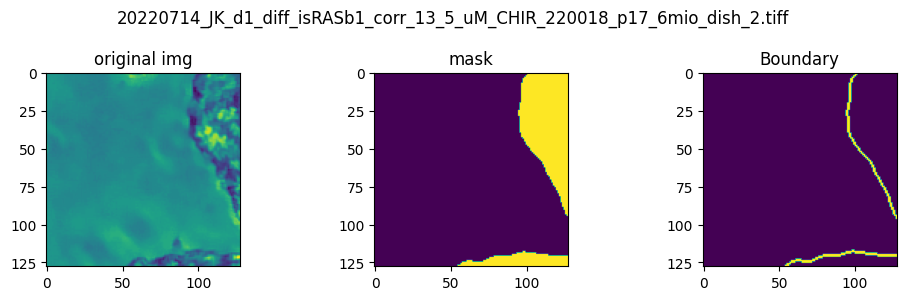

In [13]:
train_dataset = SpheroidDataset(input_folder, label_folder, patchSize = 128,transforms = False)


for i, (name, item) in enumerate(train_dataset):
# for i, item in enumerate(train_dataset):
    print(name)
#     for j, jtem in enumerate(item):
#         print(jtem)
#     print(item)
    image_patch = item[0][2].squeeze().numpy()
    mask_patch = item[1][2].squeeze().numpy()
    maskBoundary_patch = item[2][2].squeeze().numpy()
    
    plotSanityCheckImages(image_patch, mask_patch, maskBoundary_patch, f"{name}" ) # send two patches for visualisation 
    break
    if i == 1: break
# print(2+2)

In [14]:

def custom_collate_fn(batch):
    _images, _masks, _maskBoundaries, name = [], [], [], []
    for i, items in enumerate(batch):
#         name, (image_item, mask_item, maskB_item) = items[0], items[1]
        name.append(items[0])
        _images.extend(items[1][0])
        _masks.extend(items[1][1])
        _maskBoundaries.extend(items[1][2])

    images = torch.stack(_images, dim = 0)
    masks = torch.stack(_masks, dim = 0)
    maskBoundaries = torch.stack(_maskBoundaries, dim = 0)
        
    return name, (images, masks, maskBoundaries)

from torchvision.utils import make_grid
def show_batch(data_loader, batch, patchSize, _showMore = None):
    """Plot images grid of single batch"""
    for i, (name, item) in enumerate(data_loader):
        wrapped_title = str(name).replace(", ", ",\n")
#         print(f'{i+1} -> batch, with images {name},\n  -> with each items patched into-{len(item[0])} parts')
        images = item[0]
        mask = item[1]
        maskB = item[2]
        figure, ax = plt.subplots(nrows=1, ncols=3, figsize = (12, 8), sharex=True, sharey=True)
        figure.suptitle(f"batch size-{batch}, Microscopic images\n --{wrapped_title}--\n total {len(item[0])}-parts \n size {patchSize}x{patchSize}", fontsize = 12)
        ax[0].imshow(make_grid(images, nrow = batch*8, padding = 10).permute(1,2,0)) # b is from batch size above cell
        ax[1].imshow(make_grid(mask, nrow = batch*8, padding = 10).permute(1,2,0))
        ax[2].imshow(make_grid(maskB, nrow = batch*8, padding = 10).permute(1,2,0))
        plt.tight_layout
        if (i == 1) and (_showMore == False) :
            break 

            
# PatchSize = 128
# BATCH_SIZE = 4

# train_dataset = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = False)
# train_set, validation_set = torch.utils.data.random_split(train_dataset, 
#                                                           [round(len(train_dataset) * (1 - VALIDATION_SPLIT)), 
#                                                            round(len(train_dataset) * VALIDATION_SPLIT)])
# trainSteps = len(train_set) // BATCH_SIZE
# validationSteps = len(validation_set) // BATCH_SIZE

# trainLoader = DataLoader(dataset = train_set, batch_size = BATCH_SIZE, 
#                          collate_fn = custom_collate_fn, num_workers = 0, shuffle =True)
# validationLoader = DataLoader(dataset = validation_set, batch_size = BATCH_SIZE, 
#                          collate_fn = custom_collate_fn, num_workers = 0, shuffle =True)

# for epoch in tqdm(range(NUM_EPOCHS)):
#     for i, (name, item) in enumerate(trainLoader):
#         images, masks, maskBoundaries = item[0], item[1], item[2]
#         if len(name)<5:
#             print('skipping', i+1)
#             continue
#     print(f'epoch {epoch} -> batch, {len(name)}-images, with {len(item)} items(image, mask, maskB), and each patched into-{len(item[0])} parts')
# #     if i==0: break


In [15]:
PatchSize = 128
BATCH_SIZE = 2

train_dataset_1 = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = False)
train_dataset_2 = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = True)

from torch.utils.data import ConcatDataset

train_dataset = ConcatDataset([train_dataset_1, train_dataset_2])

train_set, validation_set = torch.utils.data.random_split(train_dataset, 
                                                          [round(len(train_dataset) * (1 - VALIDATION_SPLIT)), 
                                                           round(len(train_dataset) * VALIDATION_SPLIT)])
trainSteps = len(train_set) // BATCH_SIZE
validationSteps = len(validation_set) // BATCH_SIZE

trainLoader = DataLoader(dataset = train_set, batch_size = BATCH_SIZE, 
                         collate_fn = custom_collate_fn, num_workers = 0, shuffle =True)
validationLoader = DataLoader(dataset = validation_set, batch_size = BATCH_SIZE, 
                         collate_fn = custom_collate_fn, num_workers = 0, shuffle =True)
print(len(trainLoader))
# show_batch(trainLoader, batch = BATCH_SIZE, patchSize = PatchSize, _showMore = False)
# show_batch(validationLoader, batch = BATCH_SIZE, patchSize = PatchSize, _showMore = False)


86


Images with no mask--> 20230217_JK_BRAF_mc_8_p23_d9_230007.tif
Images with no mask--> 20230306_JK_230008_d12_isWT1Bld_2_261.tif
total images --> 122
total masks --> 122
transforming
torch.Size([192, 1, 128, 128])
tensor(0.2118) tensor(0.5156) tensor(0.9176)
torch.Size([192, 1, 128, 128])


original_length-->122
augmented_length-->488
Total images:  488

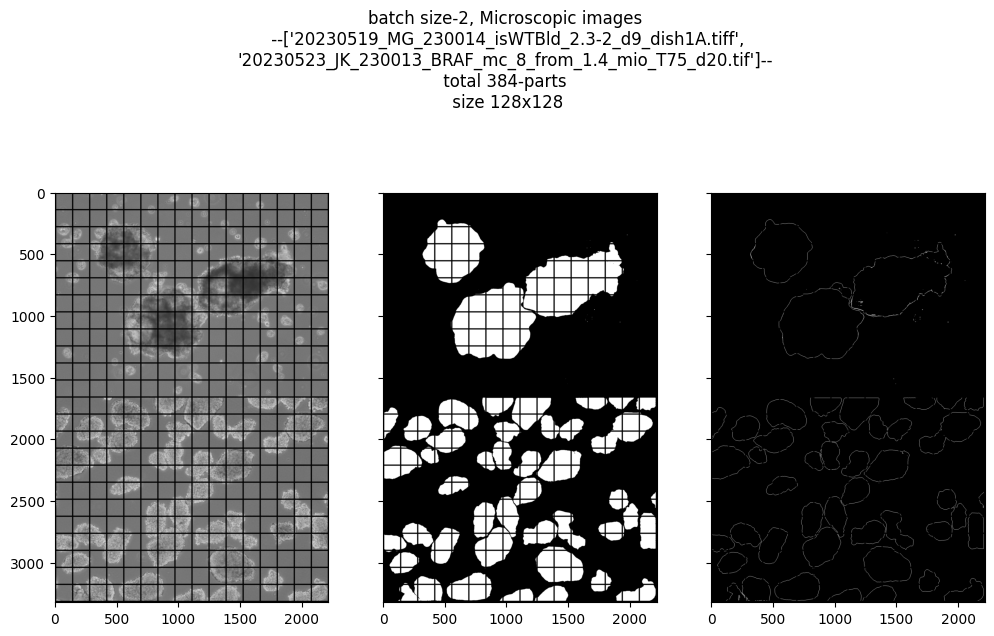

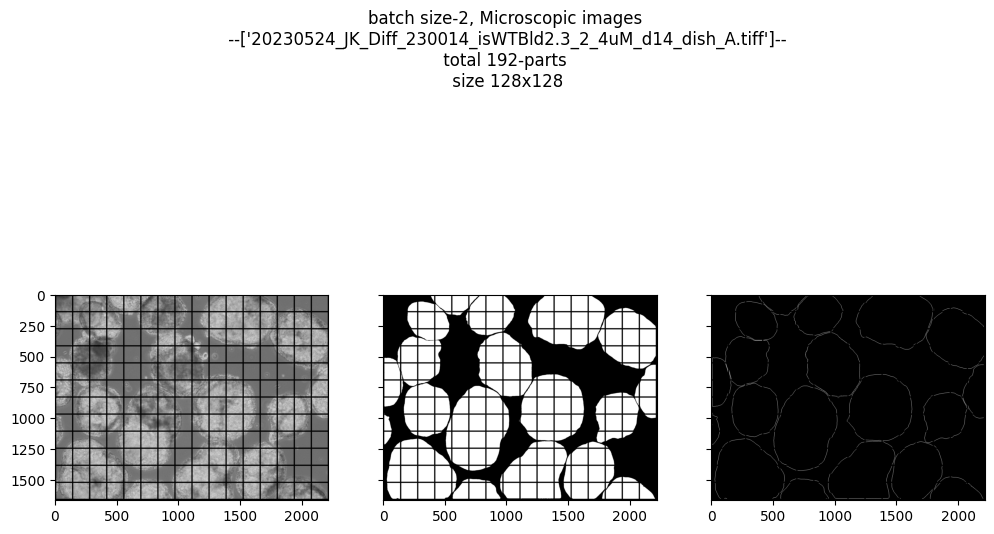

In [16]:

# for epoch in tqdm(range(NUM_EPOCHS*3)):
    
#     for i, (name, item) in enumerate(trainLoader):
#         images, masks, maskBoundaries = item[0], item[1], item[2]
#         if len(name)<5:
#             print('breaking', i+1)
#             break
#     print(f'{i+1} -> batch, {len(name)}-images, with {len(item)} items(image, mask, maskB), and each patched into-{len(item[0])} parts')
# #     if i==0: break
PatchSize = 128
BATCH_SIZE = 2


train_dataset = SpheroidDataset(test_input, test_mask ,patchSize = PatchSize, transforms = True)

# trainSteps = len(train_set) // BATCH_SIZE
# validationSteps = len(validation_set) // BATCH_SIZE

trainLoader = DataLoader(dataset = train_dataset, batch_size = BATCH_SIZE, 
                         collate_fn = custom_collate_fn, num_workers = 0, shuffle =False)

show_batch(trainLoader, batch = BATCH_SIZE, patchSize = PatchSize, _showMore = False)    
    

## LOSS Functions and Accuracy metric


In [17]:
def modelAccuracy(pred, targets):
    # Calculate pixel-wise accuracy
    # assuming input and targets afe falttened
    threshold = 0.5

    targets = torch.where(targets > threshold, torch.tensor(1), torch.tensor(0))
    pred = torch.where(pred > threshold, torch.tensor(1), torch.tensor(0))

    correct = (pred == targets)
    accuracy = correct.sum() / targets.numel()
    
    return accuracy

In [18]:
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, pred, targets, smooth=1):
        
        #comment out if your model contains a sigmoid or equivalent activation layer
        # inputs = F.sigmoid(inputs)       
        
        #flatten label and prediction tensors
        pred = pred.view(-1)
        targets = targets.view(-1)
        
        intersection = (pred * targets).sum()                            
        dice = (2.*intersection + smooth)/(pred.sum() + targets.sum() + smooth) 
        accuracy = modelAccuracy(pred, targets)
        
        return 1 - dice, accuracy

In [19]:
#PyTorch
class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, pred, targets, smooth=1):
        
        #comment out if your model contains a sigmoid or equivalent activation layer
        # inputs = F.sigmoid(inputs)       
        
        #flatten label and prediction tensors
        pred = pred.view(-1)
        targets = targets.view(-1)
        
        intersection = (pred * targets).sum()                            
        dice_loss = 1 - (2.*intersection + smooth)/(pred.sum() + targets.sum() + smooth)  
        BCE = F.binary_cross_entropy(pred, targets, reduction='mean')
        Dice_BCE = BCE + dice_loss
        
        accuracy = modelAccuracy(pred, targets)
        
        return Dice_BCE, accuracy

In [20]:
#PyTorch
ALPHA = 0.8
GAMMA = 2

class FocalLoss(nn.Module):
    # loss = model_lossFunc(pred.to(torch.float32), y.to(torch.float32))
    def __init__(self, weight=None, size_average=True):
        super(FocalLoss, self).__init__()

    def forward(self, pred, targets, alpha=ALPHA, gamma=GAMMA, smooth=1):
        #comment out if your model contains a sigmoid or equivalent activation layer
        # inputs = F.sigmoid(inputs)       
        
        #flatten label and prediction tensors
        pred = pred.view(-1) #model_predictions
        targets = targets.view(-1) #originalMasks
        
        #first compute binary cross-entropy 
        BCE = F.binary_cross_entropy(pred, targets, reduction='mean')
        BCE_EXP = torch.exp(-BCE)
        focal_loss = alpha * (1-BCE_EXP)**gamma * BCE
        
        accuracy = modelAccuracy(pred, targets)
                       
        return focal_loss, accuracy

## Building UNET

- Overall, our U-Net model will consist of an Encoder class and a Decoder class. The encoder will gradually reduce the spatial dimension to compress information. Furthermore, it will increase the number of channels, that is, the number of feature maps at each stage, enabling our model to capture different details or features in our image. On the other hand, the decoder will take the final encoder representation and gradually increase the spatial dimension and reduce the number of channels to finally output a segmentation mask of the same spatial dimension as the input image.

- Next, we define a Block module as the building unit of our encoder and decoder architecture. It is worth noting that all models or model sub-parts that we define are required to inherit from the PyTorch Module class, which is the parent class in PyTorch for all neural network modules.

## trial model with channel info outside 

In [21]:
def UNETchannels(startChanel, endChanel, num_chanel = NUM_CHANNELS):
    startPower = int(math.log2(startChanel))
    endPower = int(math.log2(endChanel))
    enCh = [num_chanel]
    deCh = []
    for num in range(startPower, endPower+1):
        enCh.append(2**num)
    deCh = enCh[::-1]
    deCh.pop()
    return tuple(enCh), tuple(deCh)

# START_CHANEL = 16
# END_CHANEL = 1024
enCh, deCh = UNETchannels(START_CHANEL, END_CHANEL)


class Block(Module):
    def __init__(self, inChannels, outChannels):
        super().__init__()
        self.conv1 = nn.Conv2d(inChannels, outChannels,
                            kernel_size=3, stride=1, padding=1, bias=True)
        self.BN1 = nn.BatchNorm2d(outChannels)
        self.relu1 = nn.ReLU(inplace = True)
        self.dropout = nn.Dropout(0.25)
            
        self.conv2 = Conv2d(outChannels, outChannels, 
                            kernel_size=3, stride=1, padding=1, bias=True)
        self.BN2 = BatchNorm2d(outChannels)
        self.relu2 = ReLU(inplace = True)
        
    def forward(self, x):
        # apply CONV => [BN] => RELU => CONV block to the inputs and return it
        outputConv1 = self.dropout(self.relu1(self.BN1(self.conv1(x))))
        outputConv2 = self.relu2(self.BN2(self.conv2(outputConv1))) 
        return outputConv2

In [22]:
'''''
class Encoder(Module):    
    def __init__(self, channels = enCh): 
        super().__init__()
        self.encBlocks = ModuleList([Block(channels[i], channels[i + 1]) 
                                      for i in range(len(channels) - 1)])
        self.pool = MaxPool2d(kernel_size=2, stride=2)

    # this takes an input image x
    # initialize an empty list (blockOutputs) to store the intermediate outputs passed
    # to the decoder where they can be processed with the decoder feature maps.   
    def forward(self, x): 
        blockOutputs = []
        for block in self.encBlocks:
            x = block(x)
            blockOutputs.append(x)
            x = self.pool(x)

        return blockOutputs

class Decoder(Module):
    def __init__(self, channels=deCh):
        super().__init__()

        self.channels = channels
        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)
                                   for i in range(len(channels) - 1)])
        self.dec_blocks = ModuleList([Block(channels[i], channels[i + 1])
                                       for i in range(len(channels) - 1)])

        # Mask prediction branch
        self.mask_conv = nn.Sequential(nn.Conv2d(channels[-1], 1, kernel_size=1), 
                                       nn.Sigmoid())
        #nn.Sequential(nn.Conv2d(decChannels[-1], nbClasses, kernel_size=1), nn.Sigmoid() )

        # Boundary prediction branch
        self.boundary_conv = nn.Sequential(nn.Conv2d(channels[-1], 1, kernel_size=1), 
                                       nn.Sigmoid())
#        nn.Conv2d(channels[-1], 1, kernel_size=1)

    def forward(self, x, encFeatures):
        for i in range(len(self.channels) - 1):
            x = self.upconvs[i](x)
            x = torch.cat([x, encFeatures[i]], dim=1)
            x = self.dec_blocks[i](x)

        # Mask prediction
        mask_pred = self.mask_conv(x)

        # Boundary prediction
        boundary_pred = self.boundary_conv(x)

        return mask_pred, boundary_pred

class UNet(Module):
    def __init__(self, encChannels=enCh,
                 decChannels=deCh,
                 nbClasses=1, retainDim=True,
                 outSize=(INPUT_IMAGE_HEIGHT, INPUT_IMAGE_WIDTH)):
        super().__init__()
        self.encoder = Encoder(encChannels)
        self.decoder = Decoder(decChannels)
        self.retainDim = retainDim
        self.outSize = outSize

    def forward(self, x):
        encFeatures = self.encoder(x)
        mask_pred, boundary_pred = self.decoder(encFeatures[::-1][0], encFeatures[::-1][1:])

        if self.retainDim:
            mask_pred = F.interpolate(mask_pred, self.outSize)
            boundary_pred = F.interpolate(boundary_pred, self.outSize)

        return mask_pred, boundary_pred

summary(UNet().to(DEVICE), input_size=(1,PATCH_SIZE,PATCH_SIZE))
'''''

"''\nclass Encoder(Module):    \n    def __init__(self, channels = enCh): \n        super().__init__()\n        self.encBlocks = ModuleList([Block(channels[i], channels[i + 1]) \n                                      for i in range(len(channels) - 1)])\n        self.pool = MaxPool2d(kernel_size=2, stride=2)\n\n    # this takes an input image x\n    # initialize an empty list (blockOutputs) to store the intermediate outputs passed\n    # to the decoder where they can be processed with the decoder feature maps.   \n    def forward(self, x): \n        blockOutputs = []\n        for block in self.encBlocks:\n            x = block(x)\n            blockOutputs.append(x)\n            x = self.pool(x)\n\n        return blockOutputs\n\nclass Decoder(Module):\n    def __init__(self, channels=deCh):\n        super().__init__()\n\n        self.channels = channels\n        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)\n                            

In [23]:
# https://pubmed.ncbi.nlm.nih.gov/33917873/       #two decodersection
class Encoder(Module):    
    def __init__(self, channels = enCh): 
        super().__init__()
        self.encBlocks = ModuleList([Block(channels[i], channels[i + 1]) 
                                      for i in range(len(channels) - 1)])
        self.pool = MaxPool2d(kernel_size=2, stride=2)

    # this takes an input image x
    # initialize an empty list (blockOutputs) to store the intermediate outputs passed
    # to the decoder where they can be processed with the decoder feature maps.   
    def forward(self, x): 
        blockOutputs = []
        for block in self.encBlocks:
            x = block(x)
            blockOutputs.append(x)
            x = self.pool(x)

        return blockOutputs
    
    
class DecoderB(Module):
    def __init__(self, channels = deCh):
        super().__init__()

        self.channels = channels
        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)
                                   for i in range(len(channels) - 1)])
        self.dec_blocks = ModuleList([Block(channels[i], channels[i + 1])
                                       for i in range(len(channels) - 1)])

    # Input is the feature map x and 
    # the list of intermediate outputs from the encoder 
    def forward(self, x, encFeatures):

        for i in range(len(self.channels) - 1):
            x = self.upconvs[i](x)
            # crop the current features from the encoder blocks,
            # concatenate them with the current upsampled features,
            # and pass the concatenated output through the current decoder block
            # encFeat = self.crop(encFeatures[i], x)
            x = torch.cat([x, encFeatures[i]], dim=1)
            x = self.dec_blocks[i](x)

        return x
    
class Decoder(Module):
    def __init__(self, channels = deCh):
        super().__init__()

        self.channels = channels
        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)
                                   for i in range(len(channels) - 1)])
        self.dec_blocks = ModuleList([Block(channels[i], channels[i + 1])
                                       for i in range(len(channels) - 1)])

    # Input is the feature map x and 
    # the list of intermediate outputs from the encoder 
    def forward(self, x, encFeatures):

        for i in range(len(self.channels) - 1):
            x = self.upconvs[i](x)
            # crop the current features from the encoder blocks,
            # concatenate them with the current upsampled features,
            # and pass the concatenated output through the current decoder block
            # encFeat = self.crop(encFeatures[i], x)
            x = torch.cat([x, encFeatures[i]], dim=1)
            x = self.dec_blocks[i](x)

        return x 

class UNet(Module):
        
    def __init__(self, encChannels = enCh,
                 decChannels = deCh, 
                 nbClasses=1, retainDim=True,
                 outSize=(INPUT_IMAGE_HEIGHT,  INPUT_IMAGE_WIDTH)):
        super().__init__()
        self.encoder = Encoder(encChannels)
        self.decoder = Decoder(decChannels)
        self.head = nn.Sequential(nn.Conv2d(decChannels[-1], nbClasses, kernel_size=1),
                                  nn.Sigmoid())
        
        self.decoderB = DecoderB(decChannels)
        self.headB = nn.Sequential(nn.Conv2d(decChannels[-1], nbClasses, kernel_size=1),
                                  nn.Sigmoid())
        self.retainDim = retainDim
        self.outSize = outSize
        
        
    def forward(self, x):
        # grab the features from the encoder
        # Note that the encFeatures list contains 
        # all the feature maps starting from the first encoder block output to the last
        encFeatures = self.encoder(x)
        # pass the encoder features through decoder making sure that
        # their dimensions are suited for concatenation
        # since the encoder feature maps starting from the last encoder block output to the first of the decoder
       
        # output of the final encoder block 
        # (i.e., encFeatures[::-1][0]) and the feature map outputs of all intermediate encoder blocks 
        # (i.e., encFeatures[::-1][1:]) to the decoder
        decFeatures = self.decoder(encFeatures[::-1][0], encFeatures[::-1][1:])
        mapS = self.head(decFeatures)
        
        decFeaturesB = self.decoderB(encFeatures[::-1][0], encFeatures[::-1][1:])
        mapB = self.headB(decFeaturesB)
        
        if self.retainDim:
            mapS = F.interpolate(mapS, self.outSize)
            mapB = F.interpolate(mapB, self.outSize)

        return mapS, mapB  
from torchsummary import summary
summary(UNet().to(DEVICE), input_size=(1,PATCH_SIZE,PATCH_SIZE))
# from torchinfo import summary
# summary(UNet(), input_size = (1,3, 128, 128), depth = 4 , verbose=0)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 128]             160
       BatchNorm2d-2         [-1, 16, 128, 128]              32
              ReLU-3         [-1, 16, 128, 128]               0
           Dropout-4         [-1, 16, 128, 128]               0
            Conv2d-5         [-1, 16, 128, 128]           2,320
       BatchNorm2d-6         [-1, 16, 128, 128]              32
              ReLU-7         [-1, 16, 128, 128]               0
             Block-8         [-1, 16, 128, 128]               0
         MaxPool2d-9           [-1, 16, 64, 64]               0
           Conv2d-10           [-1, 32, 64, 64]           4,640
      BatchNorm2d-11           [-1, 32, 64, 64]              64
             ReLU-12           [-1, 32, 64, 64]               0
          Dropout-13           [-1, 32, 64, 64]               0
           Conv2d-14           [-1, 32,

In [24]:
"""
class Encoder(Module):    
    def __init__(self, channels = enCh): 
        super().__init__()
        self.encBlocks = ModuleList([Block(channels[i], channels[i + 1]) 
                                      for i in range(len(channels) - 1)])
        self.pool = MaxPool2d(kernel_size=2, stride=2)  
    def forward(self, x): 
        blockOutputs = []
        for block in self.encBlocks:
            x = block(x)
            blockOutputs.append(x)
            x = self.pool(x)

        return blockOutputs
    
    
class Decoder(Module):
    def __init__(self, channels = deCh):
        super().__init__()

        self.channels = channels
        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)
                                   for i in range(len(channels) - 1)])
        self.dec_blocks = ModuleList([Block(channels[i], channels[i + 1])
                                       for i in range(len(channels) - 1)])

    def forward(self, x, encFeatures):

        for i in range(len(self.channels) - 1):
            x = self.upconvs[i](x)
            x = torch.cat([x, encFeatures[i]], dim=1)
            x = self.dec_blocks[i](x)

        return x  

class UNet(Module):
        
    def __init__(self, encChannels = enCh,
                 decChannels = deCh, 
                 nbClasses=1, retainDim=True,
                 outSize=(INPUT_IMAGE_HEIGHT,  INPUT_IMAGE_WIDTH)):
        super().__init__()
        self.encoder = Encoder(encChannels)
        self.decoder = Decoder(decChannels)
        self.head = nn.Sequential(nn.Conv2d(decChannels[-1], nbClasses, kernel_size=1),
                                  nn.Sigmoid() )
        self.retainDim = retainDim
        self.outSize = outSize
        
        
    def forward(self, x):
        encFeatures = self.encoder(x)
        decFeatures = self.decoder(encFeatures[::-1][0], encFeatures[::-1][1:])
        map = self.head(decFeatures)
        
        if self.retainDim:
            map = F.interpolate(map, self.outSize)

        return map   
summary(UNet().to(DEVICE), input_size=(1,PATCH_SIZE,PATCH_SIZE))
"""

'\nclass Encoder(Module):    \n    def __init__(self, channels = enCh): \n        super().__init__()\n        self.encBlocks = ModuleList([Block(channels[i], channels[i + 1]) \n                                      for i in range(len(channels) - 1)])\n        self.pool = MaxPool2d(kernel_size=2, stride=2)  \n    def forward(self, x): \n        blockOutputs = []\n        for block in self.encBlocks:\n            x = block(x)\n            blockOutputs.append(x)\n            x = self.pool(x)\n\n        return blockOutputs\n    \n    \nclass Decoder(Module):\n    def __init__(self, channels = deCh):\n        super().__init__()\n\n        self.channels = channels\n        self.upconvs = ModuleList([ConvTranspose2d(channels[i], channels[i + 1], kernel_size=2, stride=2)\n                                   for i in range(len(channels) - 1)])\n        self.dec_blocks = ModuleList([Block(channels[i], channels[i + 1])\n                                       for i in range(len(channels) - 1)])\n\n

- nbClasses: This defines the number of segmentation classes where we have to classify each pixel. This usually corresponds to the number of channels in our output segmentation map, where we have one channel for each class. Since we are working with two classes (i.e., binary classification), we keep a single channel and use thresholding for classification, as we will discuss later.

- Now the encFeatures[::-1] list contains the feature map outputs in reverse order (i.e., from the last to the first encoder block). Note that this is important since, on the decoder side, we will be utilizing the encoder feature maps starting from the last encoder block output to the first.

## checkpoints and saving of model 

In [25]:
# this is for the full model saving 
def save_checkpoint(state, filename):
    print("=> Saving complete model ")
    filename = filename + '_FullModel.pth'
    torch.save(state, filename)
    return filename
    
# this is just to save the model parameters not very comprehensive
def checkpoint_inference(model, epoch, optimizer, filename):
    print("=> Saving all model parameters ")
    filename = filename + '_ModelInference.pth'
    torch.save({
            'model': unet,
            'epoch': epoch+1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()}, filename)

## Train the UNET model

- ToPILImage(): it enables us to convert our input images to PIL image format. Note that this is necessary since we used OpenCV to load images in our custom dataset, but PyTorch expects the input image samples to be in PIL format.
- Resize(): allows us to resize our images to a particular input dimension (i.e., config.INPUT_IMAGE_HEIGHT, config.INPUT_IMAGE_WIDTH) that our model can accept
- ToTensor(): enables us to convert input images to PyTorch tensors and convert the input PIL Image, which is originally in the range from [0, 255], to [0, 1].


In [26]:




train_set, validation_set = torch.utils.data.random_split(train_dataset, 
                                                          [round(len(train_dataset) * (1 - VALIDATION_SPLIT)), 
                                                           round(len(train_dataset) * VALIDATION_SPLIT)])

In [27]:
BATCH_SIZE = 1
VALIDATION_SPLIT = 0.3
# NUM_WORKERS
PatchSize = 128
train_dataset_1 = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = False)
train_dataset_2 = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = True)
from torch.utils.data import ConcatDataset

# train_dataset = ConcatDataset([train_dataset_1, train_dataset_2])
train_dataset = SpheroidDataset(input_folder, label_folder,patchSize = PatchSize, transforms = False)

train_set, validation_set = torch.utils.data.random_split(train_dataset, 
                                                          [round(len(train_dataset) * (1 - VALIDATION_SPLIT)), 
                                                           round(len(train_dataset) * VALIDATION_SPLIT)])


trainLoader = DataLoader(dataset = train_set, batch_size = BATCH_SIZE, collate_fn = custom_collate_fn, 
                         num_workers = 0, shuffle = True)
validationLoader = DataLoader(dataset = validation_set, batch_size = BATCH_SIZE, collate_fn = custom_collate_fn, 
                              num_workers = 0, shuffle =True) 

# calculate steps per epoch for training and test set

trainSteps = len(train_set) // BATCH_SIZE
validationSteps = len(validation_set) // BATCH_SIZE

print(f"Total {len(train_set)} instances in the training and {trainSteps} per epoch")
print(f"Total {len(validation_set)} instances in the validation set and {validationSteps} per epoch")
print(f"Each Epoch runs: {len(trainLoader)} times, where each loader has {BATCH_SIZE} instances for trainig")
print(f"ModelName-{plotName}\n")

trainLoader = DataLoader(dataset = train_set, batch_size = BATCH_SIZE, collate_fn = custom_collate_fn, num_workers = NUM_WORKERS, shuffle =True)


gpu_usage() 

Total 85 instances in the training and 85 per epoch
Total 37 instances in the validation set and 37 per epoch
Each Epoch runs: 85 times, where each loader has 1 instances for trainig
ModelName-bSz1_ip128_EnDc16-256_ep2_vls0.3_aug3_nW0

| ID | GPU | MEM |
------------------


In [30]:
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

MPS not available because the current MacOS version is not 12.3+ and/or you do not have an MPS-enabled device on this machine.


In [31]:
# DEVICE = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cuda')
DEVICE = torch.device("cpu")
unet = UNet()
# unet = nn.DataParallel(unet)
unet.to(DEVICE)
# initialize loss function and optimizerimizer
metric_lossFunc = DiceBCELoss() #nn.BCELoss() #
boundaryLoss = DiceBCELoss() #DiceLoss()
optimizer = optim.Adam(unet.parameters(), lr= 1e-2, weight_decay = WEIGHT_DECAY)

gpu_usage()

trainSteps = len(train_set) // BATCH_SIZE
validationSteps = len(validation_set) // BATCH_SIZE
print(trainSteps, validationSteps)
print(DEVICE)


print(torch.backends.mps.is_available())




| ID | GPU | MEM |
------------------
85 37
cpu
False


In [32]:
# initialize a dictionary to store training history
H = {"train_loss": [], "train_loss_B": [], "validation_loss": [], "validation_loss_B": [], "model_accuracy":[]}
# loop over epochs
print("[INFO] training the network...")
startTime = time.time()
NUM_EPOCHS = 10

for epoch in tqdm(range(NUM_EPOCHS)):
    # set the model in training mode - initialise train and val loss - loop on train set
    unet.train()
    totalTrainLoss, totalTrainLoss_B = 0, 0
    totalValLoss, totalValLoss_B = 0, 0
    totalAccuracy, totalAccuracy_B = 0, 0
    print(f"\nRunning epoch:- {epoch+1}")
    print(f"the model runs -> {len(trainLoader)} times")
    
    print('\n\nTrain section')
    for i, (_, item) in enumerate(trainLoader):
        print(f'item: {len(item)}, i-{i}')
        try:
#             print(item)
            if len(item) != 3:
                print(i, len(item))
                continue
            img = item[0]
            mask = item[1]
            maskB = item[2]
            (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE))
            mask_pred, boundary_pred = unet(img)
            print(f'mask_pred, {mask_pred.shape}, boundary_pred {boundary_pred.shape}')
            
        except Exception as e:
            print(f"Exception occurred during training: {e}")
            traceback.print_exc()
            # Optionally, you can try to recover from the exception
            # by skipping the current batch or performing any necessary cleanup
            continue

#     print(f'totalTrainLoss: {totalTrainLoss}, totalTrainLoss_B: {totalTrainLoss_B}, combined_loss: {combined_loss}')

    # switch off autograd for validation set
    print('\n\nvalidation section')
    with torch.no_grad():
        unet.eval()
        for i, (_, item) in enumerate(validationLoader):
            print(f'item: {len(item)}')
            try:
                if len(item) != 3:
                    print(i, len(item))
                    continue
                img = item[0]
                mask = item[1]
                maskB = item[2]
                (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE))
                mask_pred, boundary_pred = unet(img)
                print(f'mask_pred, {mask_pred.shape}, boundary_pred {boundary_pred.shape}')

            except Exception as e:
                print(f"Exception occurred during validation: {e}")
                traceback.print_exc()
                # Optionally, you can try to recover from the exception
                # by skipping the current batch or performing any necessary cleanup
                continue
    gpu_usage()

endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())


[INFO] training the network...


  0%|          | 0/10 [00:00<?, ?it/s]


Running epoch:- 1
the model runs -> 85 times


Train section
item: 3, i-0
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-1
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-2
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-3
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-4
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-5
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-6
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
item: 3, i-7


  0%|          | 0/10 [01:54<?, ?it/s]


KeyboardInterrupt: 

In [41]:
# initialize a dictionary to store training history
H = {"train_loss": [], "train_loss_B": [], "validation_loss": [], "validation_loss_B": [], "model_accuracy":[]}
# loop over epochs
print("[INFO] training the network...")
startTime = time.time()
NUM_EPOCHS = 10

for epoch in tqdm(range(NUM_EPOCHS)):
    # set the model in training mode - initialise train and val loss - loop on train set
    unet.train()
    totalTrainLoss, totalTrainLoss_B = 0, 0
    totalValLoss, totalValLoss_B = 0, 0
    totalAccuracy, totalAccuracy_B = 0, 0
    print(f"\nRunning epoch:- {epoch+1}")
    print(f"the model runs -> {len(trainLoader)} times")
    
    print('\n\nTrain section')
    for i, (_, item) in enumerate(trainLoader):
        print(f'item: {len(item)}, i-{i}')
        try:
#             print(item)
            if len(item) != 3:
                print(i, len(item))
                continue
            img = item[0]
            mask = item[1]
            maskB = item[2]
            (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE))
            mask_pred, boundary_pred = unet(img)
            print(f'mask_pred, {mask_pred.shape}, boundary_pred {boundary_pred.shape}')

            loss, accuracy = metric_lossFunc(mask_pred, mask)  # DiceBCELoss
            lossB, accuracyB = boundaryLoss(boundary_pred, maskB)
            combined_loss = loss + lossB
            print(f'loss:{loss}, lossB:{lossB}')

            optimizer.zero_grad()
            combined_loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            totalTrainLoss_B += lossB.item()
            print(f'totalTrainLoss: {totalTrainLoss}, totalTrainLoss_B: {totalTrainLoss_B}, combined_loss: {combined_loss}')
        except Exception as e:
            print(f"Exception occurred during training: {e}")
            traceback.print_exc()
            # Optionally, you can try to recover from the exception
            # by skipping the current batch or performing any necessary cleanup
            continue

#     print(f'totalTrainLoss: {totalTrainLoss}, totalTrainLoss_B: {totalTrainLoss_B}, combined_loss: {combined_loss}')

    # switch off autograd for validation set
    print('\n\nvalidation section')
    with torch.no_grad():
        unet.eval()
        for i, (_, item) in enumerate(validationLoader):
            print(f'item: {len(item)}')
            try:
                if len(item) != 3:
                    print(i, len(item))
                    continue
                img = item[0]
                mask = item[1]
                maskB = item[2]
                (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE))
                mask_pred, boundary_pred = unet(img)
                print(f'mask_pred, {mask_pred.shape}, boundary_pred {boundary_pred.shape}')

                loss, accuracy = metric_lossFunc(mask_pred, mask)  # DiceBCELoss
                lossB, accuracyB = boundaryLoss(boundary_pred, maskB)

                combined_loss = loss.item() + lossB.item()
                print(f'loss:{loss}, lossB:{lossB}')

                totalValLoss += loss.item()
                totalValLoss_B += lossB.item()
                totalAccuracy += accuracy.item()
                totalAccuracy_B += accuracyB.item()
                print(f'totalValLoss: {totalValLoss}, totalValLoss_B: {totalValLoss_B}, combined_loss: {combined_loss}')
            except Exception as e:
                print(f"Exception occurred during validation: {e}")
                traceback.print_exc()
                # Optionally, you can try to recover from the exception
                # by skipping the current batch or performing any necessary cleanup
                continue

    # calculate the average training and validation loss and binary accuracy
    avgTrainLoss = totalTrainLoss / trainSteps
    avgTrainLoss_B = totalTrainLoss_B / trainSteps
    avgValidationLoss = totalValLoss / validationSteps
    avgValidationLoss_B = totalValLoss_B / validationSteps
    avgAcc = totalAccuracy / validationSteps

    H["train_loss"].append(avgTrainLoss)
    H["train_loss_B"].append(avgTrainLoss_B)
    H["validation_loss"].append(avgValidationLoss)
    H["validation_loss_B"].append(avgValidationLoss_B)
    H["model_accuracy"].append(avgAcc)

    # print the model training and validation information
    # print(f"For EPOCH: {epoch + 1}/{NUM_EPOCHS}, and model goes through data->{len(trainLoader)} times}")
    # print(f"Train loss: {avgTrainLoss:.6f}, Validation loss: {avgValidationLoss:.4f},Val accuracy: {avgAcc:.4f}")
    # print(f"Boundary_Loss: {avgTrainLoss_B:.6f}, Validation Boundary_Loss: {avgValidationLoss_B:.4f}")
    gpu_usage()

    # if avgTrainLoss==0 or avgValidationLoss==0:
    #     print('xxxxxxxx-- stopping the run --xxxxxxxxxxx')
    #     break
    torch.save(unet, MODEL_PATH)

endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())


[INFO] training the network...


  0%|          | 0/10 [00:00<?, ?it/s]


Running epoch:- 1
the model runs -> 85 times


Train section
item: 3, i-0
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:1.232204794883728, lossB:1.4696861505508423
totalTrainLoss: 1.232204794883728, totalTrainLoss_B: 1.4696861505508423, combined_loss: 2.7018909454345703
item: 3, i-1
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:1.0765626430511475, lossB:1.4066808223724365
totalTrainLoss: 2.3087674379348755, totalTrainLoss_B: 2.876366972923279, combined_loss: 2.483243465423584
item: 3, i-2
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.920147180557251, lossB:1.3533987998962402
totalTrainLoss: 3.2289146184921265, totalTrainLoss_B: 4.229765772819519, combined_loss: 2.273545980453491
item: 3, i-3
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.819806694984436, lossB:1.3202883005142212
totalTrainLoss: 4.

 10%|█         | 1/10 [00:50<07:35, 50.61s/it]


Running epoch:- 2
the model runs -> 85 times


Train section
item: 3, i-0
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.42234131693840027, lossB:0.8319008350372314
totalTrainLoss: 0.42234131693840027, totalTrainLoss_B: 0.8319008350372314, combined_loss: 1.254242181777954
item: 3, i-1
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.36064648628234863, lossB:0.8330713510513306
totalTrainLoss: 0.7829878032207489, totalTrainLoss_B: 1.664972186088562, combined_loss: 1.1937178373336792
item: 3, i-2
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.2851674556732178, lossB:0.7680789828300476
totalTrainLoss: 1.0681552588939667, totalTrainLoss_B: 2.4330511689186096, combined_loss: 1.0532464981079102
item: 3, i-3
mask_pred, torch.Size([192, 1, 128, 128]), boundary_pred torch.Size([192, 1, 128, 128])
loss:0.3029455542564392, lossB:0.7624242901802063
totalTrai

...


Running epoch:- 9
the model runs -> 85 times


Train section


validation section
| ID | GPU | MEM |
------------------
|  0 |  1% | 34% |
|  1 |  0% | 33% |


 90%|█████████ | 9/10 [03:36<00:13, 13.62s/it]


Running epoch:- 10
the model runs -> 85 times


Train section


validation section
| ID | GPU | MEM |
------------------
|  0 |  0% | 34% |
|  1 |  0% | 33% |


100%|██████████| 10/10 [03:46<00:00, 22.62s/it]

[INFO] total time taken to train the model: 226.21s
| ID | GPU | MEM |
------------------
|  0 |  1% |  3% |
|  1 |  0% |  1% |
None


In [ ]:
with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())

In [ ]:
# initialize a dictionary to store training history
H = {"train_loss": [], "train_loss_B": [], "validation_loss": [], "validation_loss_B": [], "model_accuracy":[]}
# loop over epochs
print("[INFO] training the network...")
startTime = time.time()
NUM_EPOCHS = 3
for epoch in tqdm(range(NUM_EPOCHS)):
    # set the model in training mode - initialise train and val loss - loop on train set
    unet.train()
    totalTrainLoss, totalTrainLoss_B = 0, 0
    totalValLoss, totalValLoss_B = 0, 0
    totalAccuracy, totalAccuracy_B = 0, 0
    print(f"\n\nRunning epoch:- {epoch+1}")
    print(f"the model runs -> {len(trainLoader)} times")
    
    
    for i, (name, item) in enumerate(trainLoader):
        print(name)
        img = item[0]
        mask = item[1]
        maskB = item[2]
        (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE)) 
        mask_pred, boundary_pred = unet(img)

        loss, accuracy = metric_lossFunc(mask_pred, mask) #DiceBCELoss
        lossB, accuracyB = boundaryLoss(boundary_pred, maskB)
        combined_loss = loss + lossB
        
        optimizer.zero_grad()
        combined_loss.backward()
        optimizer.step()
    
        totalTrainLoss += loss.item()
        totalTrainLoss_B += lossB.item()
            
#         print(f'loss- {loss.item()}, lossB- {lossB.item()}')
    print(f'totalTrainLoss: {totalTrainLoss}, totalTrainLoss_B: {totalTrainLoss_B}, combined_loss: {combined_loss}')
        
    # switch off autograd for validation set
    with torch.no_grad():
        unet.eval()
        for i, (name, item) in enumerate(validationLoader):
            """ Note make sure to change the i/p channel to later on ([-1, 1, patch_size, patch_size])"""
#             if len(name) < BATCH_SIZE:
#                 print('breaking', i+1)
#                 continue
            if name:
                img = item[0]
                mask = item[1]
                maskB = item[2]
                (img, mask, maskB) = (img.to(DEVICE), mask.to(DEVICE), maskB.to(DEVICE))
                mask_pred, boundary_pred = unet(img)

                loss, accuracy = metric_lossFunc(mask_pred, mask) #DiceBCELoss
                lossB, accuracyB = boundaryLoss(boundary_pred, maskB)
            
                combined_loss = loss.item() + lossB.item()
            
                totalValLoss += loss.item()
                totalValLoss_B += lossB.item()
                totalAccuracy += accuracy.item()
                totalAccuracy_B += accuracyB.item()
            elif len(item) !=3:
                print(i, name, len(item))
                continue
#             print(f'loss- {loss.item()}, lossB- {lossB.item()}')
    print(f'totalValLoss: {totalValLoss}, totalValLoss_B: {totalValLoss_B}, combined_loss: {combined_loss}')
            # print(f'Device:{DEVICE}, totalAccuracy:{totalAccuracy}, acc:{acc}')
            
    # calculate the average training and validation loss and binary accuracy
    avgTrainLoss = totalTrainLoss / trainSteps
    avgTrainLoss_B = totalTrainLoss_B / trainSteps
    avgValidationLoss = totalValLoss / validationSteps
    avgValidationLoss_B = totalValLoss_B / validationSteps
    avgAcc = totalAccuracy / validationSteps
    
    H["train_loss"].append(avgTrainLoss)
    H["train_loss_B"].append(avgTrainLoss_B)
    H["validation_loss"].append(avgValidationLoss) 
    H["validation_loss_B"].append(avgValidationLoss_B) 
    H["model_accuracy"].append(avgAcc) 
    
    # print the model training and validation information
#     print(f"For EPOCH: {epoch + 1}/{NUM_EPOCHS}, and model goes through data->{len(trainLoader)} times)")
#     print(f"Train loss: {avgTrainLoss:.6f}, Validation loss: {avgValidationLoss:.4f},Val accuracy: {avgAcc:.4f}")
#     print(f"Boundary_Loss: {avgTrainLoss_B:.6f}, Validation Boundary_Loss: {avgValidationLoss_B:.4f}")
    gpu_usage()

#     if avgTrainLoss==0 or avgValidationLoss==0:
#         print('xxxxxxxx-- stopping the run --xxxxxxxxxxx')
#         break
    torch.save(unet, MODEL_PATH)
    
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))

with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())

In [ ]:
# print("[INFO] total time taken to train the model: {:.2f}min".format((endTime - startTime)/60))

# print(H["train_loss"])
# print(H["train_loss_B"])
# print(H["validation_loss"])
# print(H["validation_loss_B"])/

# print(H["model_accuracy"])
with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())

In [ ]:
# save the final model and check_point inference if the mdel training completes with no issues
# MODEL_PATH = save_checkpoint(unet, MODEL_PATH)
# checkpoint_inference(unet,  epoch, optimizer, MODEL_PATH)
print("[INFO] total time taken to train the model: {:.2f}min".format((endTime - startTime)/60))

print(H["train_loss"])
print(H["train_loss_B"])
print(H["validation_loss"])
print(H["validation_loss_B"])
print(H["model_accuracy"])

In [ ]:


plt.style.use("ggplot")
plt.figure()
plt.plot(H["train_loss"], label="train_loss")
plt.plot(H["train_loss_B"], label="train_loss_B")
plt.plot(H["validation_loss_B"], label="validation_loss_B")
plt.plot(H["validation_loss"], label="validation_loss")
plt.title(f"Losses for model:-\n{plotName}")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend(loc="lower left")

plt.savefig(f"LossPlot_{plotName}.png")

In [ ]:
plt.plot(H["model_accuracy"], label="accuracy")
plt.title(f"Accuracy for model:-\n{plotName}")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend(loc="upper left")
plt.savefig(f"AccuracyPlot_{plotName}.png")


# Model used for prediction of segemnted images

In [ ]:

def prepare_plot(origImage, origMask, origMaskBoundary, predMask, predMaskBoundary, file, threshold = None):
    # initialize our figure
    figure, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
    ax[0][0].imshow(origImage)
    ax[0][1].imshow(origMask)
    ax[0][2].imshow(predMask)
    ax[1][0].imshow(origMaskBoundary)
    ax[1][1].imshow(predMaskBoundary)
    ax[1][2].imshow(predMask)
#     ax[3].imshow(predMask > (predMask.max() - threshold))
#     ax[3].hist(predMask.flatten()*255)

    ax[0][0].set_title(f"{file}")
    ax[0][1].set_title("Original Mask")
    ax[0][2].set_title(f"P_Mask-{threshold}thresh")
    ax[1][0].set_title(f"orig Boundary")
    ax[1][1].set_title("pred Mask Boundary")
    ax[1][2].set_title(f"All combined")
#     ax[3].set_title('P_mask w threshold')

    figure.tight_layout()
    figure.show()

def make_predictions(model, file, imagePath, groundTruthPath, patch_size, threshold = None):
    model.eval()
    with torch.no_grad():
        image = Image.open(imagePath).convert("L")
        image = np.float32(image)/255.0
        
        gtMask = np.array(Image.open(groundTruthPath).convert("L"))
        gtMask[gtMask > 0] = 1.0
        gtMask_Boundary = find_boundaries(np.array(Image.open(groundTruthPath).convert("L")), mode='thick').astype(np.uint8)
#         find_boundaries(np.array(img), mode='thick').astype(np.uint8)
        #gtMask_Boundary = np.where(np.array(gtMask_Boundary) > 0, 1.0, 0.0)
        gtMask_Boundary[gtMask_Boundary > 0] = 1.0
    
        height, width = image.shape[:2]
        segm_img = np.zeros((height, width), dtype=np.uint8)  # Array with zeros to be filled with segmented values
        segmBoundary_img = np.zeros((height, width), dtype=np.uint8)
    
        patch_num = 1
    
        for i in range(0, height, patch_size):  
            for j in range(0, width, patch_size):  
                single_patch = image[i:i+patch_size, j:j+patch_size]
                single_patch = np.expand_dims(np.expand_dims(single_patch, 0), 0)
                orig_patch = single_patch.copy()
                single_patch = torch.from_numpy(single_patch).to(DEVICE)
                
                Mask_patch = gtMask[i:i+patch_size, j:j+patch_size]
               
                # pass the results through the sigmoid if the last layer of the model doesnot do sigmoid conversion
                # single_patch_prediction = torch.sigmoid(model(single_patch)).squeeze().cpu().numpy()
                single_patch_prediction, singleBoundary_patch_prediction = model(single_patch) #.squeeze().cpu().numpy()
                
                # filter out the weak predictions and convert them to integers
                single_patch_prediction = ((single_patch_prediction.squeeze().cpu().numpy() > threshold)*255).astype(np.uint8)
                single_patch_shape = single_patch_prediction.shape[:2]
                segm_img[i:i+single_patch_shape[0], j:j+single_patch_shape[1]] += cv2.resize(single_patch_prediction, single_patch_shape[::-1])
                
                # singleBoundary_patch_prediction = ((singleBoundary_patch_prediction.squeeze().cpu().numpy())).astype(np.uint8)
                singleBoundary_patch_prediction = ((singleBoundary_patch_prediction.squeeze().cpu().numpy() > threshold)*255).astype(np.uint8)
                single_patch_shape = singleBoundary_patch_prediction.shape[:2]
                segmBoundary_img[i:i+single_patch_shape[0], j:j+single_patch_shape[1]] += cv2.resize(singleBoundary_patch_prediction, single_patch_shape[::-1])
                # print("Finished processing patch number ", patch_num, " at position ", i, j)
            
            patch_num += 1  
        print(singleBoundary_patch_prediction.max(), singleBoundary_patch_prediction.min())

    prepare_plot(image, gtMask, gtMask_Boundary, segm_img, segmBoundary_img, file, threshold)
    return single_patch_prediction



In [ ]:

print("[INFO] load up model...")
model = torch.load(MODEL_PATH).to(DEVICE)
print("[INFO] loading up test image paths...\n")
test_input = '/kaggle/input/myofarm/test_inputs'
test_mask = '/kaggle/input/myofarm/test_masks'

files = os.listdir(test_input)
for file in files:
    imagePath = test_input+ '/' + file
    groundTruthPath = test_mask + '/' + '.'.join(file.split('.')[:-1]) + '_bn.tif'
    simg = make_predictions(unet, file, imagePath, groundTruthPath, PATCH_SIZE, threshold = 0.5)
    break



In [ ]:
with torch.no_grad():
    torch.cuda.empty_cache()
print(gpu_usage())
# imagePaths = []


# test_input = '/kaggle/input/myofarm/test_inputs'
# test_mask = '/kaggle/input/myofarm/test_masks'
# files = np.random.choice(os.listdir(test_input), size = 4)
# for file in files:
#     imagePath = test_input+ '/' + file
#     image = np.array(Image.open(imagePath).convert("L"))
#     plt.imshow(image)
#     plt.show()
#     groundTruthPath = test_mask + '/' + '.'.join(file.split('.')[:-1]) + '_bn.tif'
#     image = np.array(Image.open(groundTruthPath).convert("L"))
#     image[image > 0] = 1.0
#     plt.imshow(image)
#     plt.show()
#     print(imagePath, groundTruthPath)